# 2026 UNF Baseball — Performance Analysis & Benchmarking
## North Florida Ospreys vs NCAA Tournament Field

**Author:** Richard Naumann 
**Program:** MS Business Analytics — University of North Florida  
**Date:** 2026  

---

### Project Overview
This analysis benchmarks UNF's 2026 baseball season (31-24, 
ASUN Graphite Division Champions) against the full 64-team 
2026 NCAA Tournament field using advanced metrics including 
FIP, wOBA, OPS, WHIP, and percentile rankings across 17 
statistical categories.

### Key Findings
- Pitching ranks 67.7th percentile vs tournament field
- Offense ranks 14.4th percentile vs tournament field  
- Defense ranks 10.2th percentile vs tournament field
- Linear regression model achieves R-squared of 0.891
  predicting run production from OBP and SLG

### Tools Used
Python, pandas, numpy, matplotlib, seaborn, scikit-learn

## Section 1 — Imports and Setup
Loading all required libraries and the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import os
import subprocess
subprocess.run(['pip', 'install', 'openpyxl'])
import os
print(os.getcwd())
import sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'openpyxl'])
print("All libraries loaded successfully")

/Users/richardnaumann
All libraries loaded successfully


You should consider upgrading via the '/Library/Frameworks/Python.framework/Versions/3.9/bin/python3.9 -m pip install --upgrade pip' command.


In [2]:
df = pd.read_excel('team_benchmarks_Final.xlsx')

df['K_total']    = ((df['K_per_9']  / 9) * df['Innings_pitched']).round(0)
df['BB_total']   = ((df['BB_per_9'] / 9) * df['Innings_pitched']).round(0)
df['HR_allowed'] = ((df['HR_per_9'] / 9) * df['Innings_pitched']).round(0)
df['FIP_core']   = (13*df['HR_allowed'] + 3*df['BB_total'] - 2*df['K_total']) / df['Innings_pitched']

FIP_C            = round(df['ERA'].mean() - df['FIP_core'].mean(), 2)
df['FIP_approx'] = (df['FIP_core'] + FIP_C).round(2)

unf        = df[df['team'] == 'North Florida'].iloc[0]
tournament = df[df['ncaa_tournament_regional'] == 1].copy()

print(f"Dataset loaded: {len(df)} teams")
print(f"Tournament field: {len(tournament)} teams")
print(f"FIP constant: {FIP_C}")
print(f"\nUNF ERA: {unf['ERA']}")
print(f"UNF FIP: {unf['FIP_approx']}")

Dataset loaded: 65 teams
Tournament field: 64 teams
FIP constant: 4.16

UNF ERA: 4.62
UNF FIP: 4.53


## Section 3 — Percentile Benchmarking
Calculating UNF's percentile rank across 17 statistics
vs the 64 team NCAA Tournament field. For higher is better
stats, percentile equals the percentage of tournament teams
UNF beats. For lower is better stats the comparison flips.

In [3]:
stats = [
    ('Batting Avg',   'batting_avg',     'higher'),
    ('OBP',           'OBP',             'higher'),
    ('SLG',           'SLG',             'higher'),
    ('OPS',           'OPS',             'higher'),
    ('ISO',           'ISO',             'higher'),
    ('Runs/Game',     'runs_per_game',   'higher'),
    ('wOBA',          'wOBA_approx',     'higher'),
    ('K% Off',        'K_pct_off',       'lower'),
    ('BB% Off',       'BB_pct_off',      'higher'),
    ('ERA',           'ERA',             'lower'),
    ('FIP',           'FIP_approx',      'lower'),
    ('WHIP',          'WHIP',            'lower'),
    ('K/9',           'K_per_9',         'higher'),
    ('BB/9',          'BB_per_9',        'lower'),
    ('HR/9 Allowed',  'HR_per_9',        'lower'),
    ('Fielding %',    'fielding_pct',    'higher'),
    ('Errors/Game',   'errors_per_game', 'lower'),
]

results = []
for label, col, direction in stats:
    unf_val  = unf[col]
    t_vals   = tournament[col].dropna()
    t_mean   = t_vals.mean()
    t_median = t_vals.median()

    if direction == 'higher':
        pct = (t_vals < unf_val).sum() / len(t_vals) * 100
    else:
        pct = (t_vals > unf_val).sum() / len(t_vals) * 100

    gap = unf_val - t_mean

    results.append({
        'stat':       label,
        'unf':        round(unf_val, 3),
        'tourn_avg':  round(t_mean, 3),
        'tourn_med':  round(t_median, 3),
        'percentile': round(pct, 1),
        'gap':        round(gap, 3),
        'direction':  direction,
    })

results_df = pd.DataFrame(results)

def tier(pct):
    if pct >= 75:
        return 'STRENGTH'
    elif pct >= 40:
        return 'AVERAGE'
    else:
        return 'GAP'

results_df['tier'] = results_df['percentile'].apply(tier)

cat_map = {
    'Batting Avg':  'Offense',  'OBP':          'Offense',
    'SLG':          'Offense',  'OPS':           'Offense',
    'ISO':          'Offense',  'Runs/Game':     'Offense',
    'wOBA':         'Offense',  'K% Off':        'Offense',
    'BB% Off':      'Offense',  'ERA':           'Pitching',
    'FIP':          'Pitching', 'WHIP':          'Pitching',
    'K/9':          'Pitching', 'BB/9':          'Pitching',
    'HR/9 Allowed': 'Pitching', 'Fielding %':    'Defense',
    'Errors/Game':  'Defense',
}

results_df['category'] = results_df['stat'].map(cat_map)

summary = results_df.groupby('category')['percentile'].mean().round(1)

print("=== CATEGORY SUMMARY ===")
print(summary)
print(f"\n=== STRENGTHS ===")
print(results_df[results_df['tier'] == 'STRENGTH'][['stat', 'unf', 'tourn_avg', 'percentile']])
print(f"\n=== AVERAGE ===")
print(results_df[results_df['tier'] == 'AVERAGE'][['stat', 'unf', 'tourn_avg', 'percentile']])
print(f"\n=== GAPS ===")
print(results_df[results_df['tier'] == 'GAP'][['stat', 'unf', 'tourn_avg', 'percentile']])

=== CATEGORY SUMMARY ===
category
Defense     10.2
Offense     14.4
Pitching    67.7
Name: percentile, dtype: float64

=== STRENGTHS ===
            stat   unf  tourn_avg  percentile
10           FIP  4.53      5.107        85.9
14  HR/9 Allowed  0.66      1.123       100.0

=== AVERAGE ===
       stat    unf  tourn_avg  percentile
8   BB% Off  0.147      0.140        67.2
9       ERA  4.620      5.102        70.3
11     WHIP  1.400      1.447        57.8
13     BB/9  4.200      4.202        53.1

=== GAPS ===
           stat    unf  tourn_avg  percentile
0   Batting Avg  0.261      0.287         3.1
1           OBP  0.369      0.393         4.7
2           SLG  0.409      0.470         6.2
3           OPS  0.778      0.864         3.1
4           ISO  0.148      0.183        18.8
5     Runs/Game  5.950      7.265         4.7
6          wOBA  0.344      0.377         3.1
7        K% Off  0.259      0.234        18.8
12          K/9  8.900      9.343        39.1
15   Fielding %  0.965  

## Section 4 — Visualizations
Eight charts illustrating UNF's performance vs the NCAA
Tournament field. Charts saved as PNG files for portfolio
and GitHub upload.

Folders created successfully


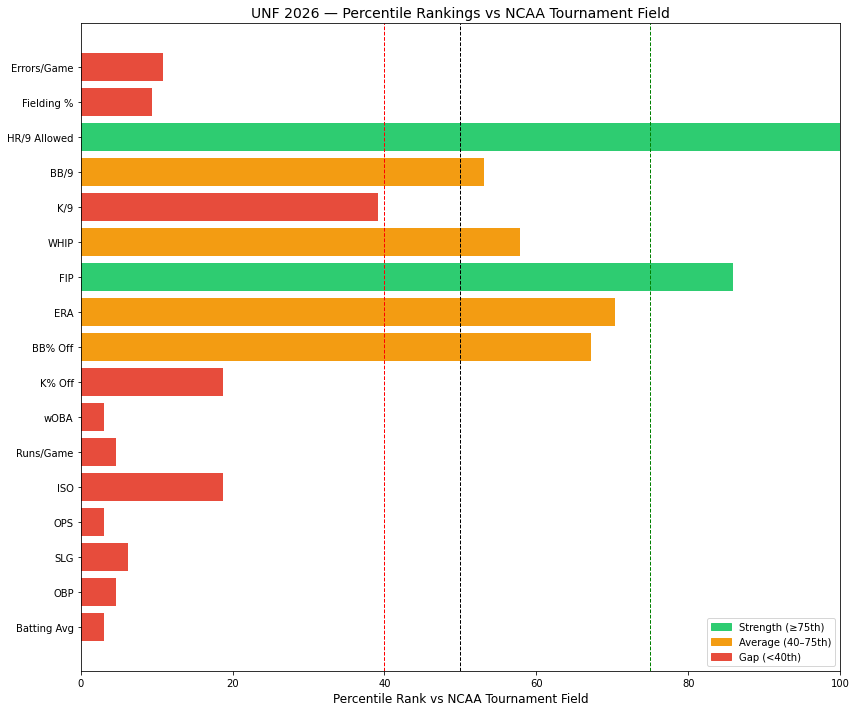

Chart 1 saved


In [4]:
import os

os.makedirs('charts', exist_ok=True)
os.makedirs('data',   exist_ok=True)

print("Folders created successfully")

# Chart 1 — Gap Bar Chart
fig, ax = plt.subplots(figsize=(12, 10))

colors = []
for t in results_df['tier']:
    if t == 'STRENGTH':
        colors.append('#2ecc71')
    elif t == 'AVERAGE':
        colors.append('#f39c12')
    else:
        colors.append('#e74c3c')

ax.barh(results_df['stat'], results_df['percentile'], color=colors)
ax.axvline(x=50, color='black', linestyle='--', linewidth=1)
ax.axvline(x=75, color='green', linestyle='--', linewidth=1)
ax.axvline(x=40, color='red',   linestyle='--', linewidth=1)
ax.set_xlabel('Percentile Rank vs NCAA Tournament Field', fontsize=12)
ax.set_title('UNF 2026 — Percentile Rankings vs NCAA Tournament Field', fontsize=14)
ax.set_xlim(0, 100)

strength_patch = mpatches.Patch(color='#2ecc71', label='Strength (≥75th)')
average_patch  = mpatches.Patch(color='#f39c12', label='Average (40–75th)')
gap_patch      = mpatches.Patch(color='#e74c3c', label='Gap (<40th)')
ax.legend(handles=[strength_patch, average_patch, gap_patch], loc='lower right')

plt.tight_layout()
plt.savefig('charts/chart1_gap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved")

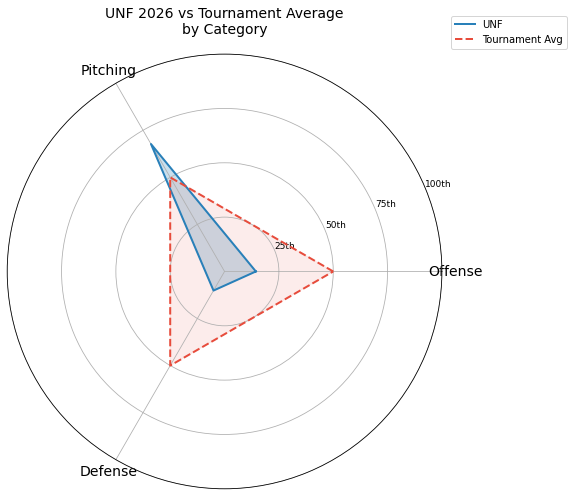

Chart 2 saved


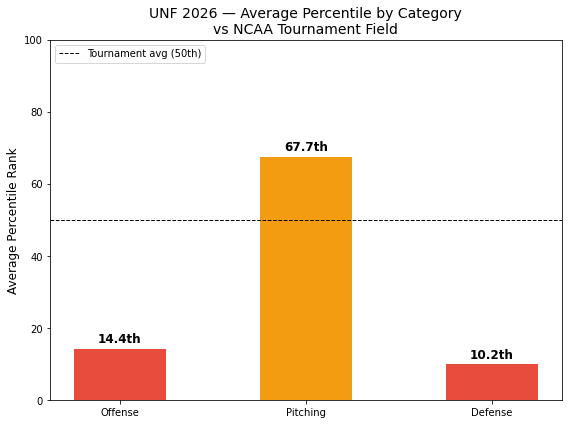

Chart 3 saved


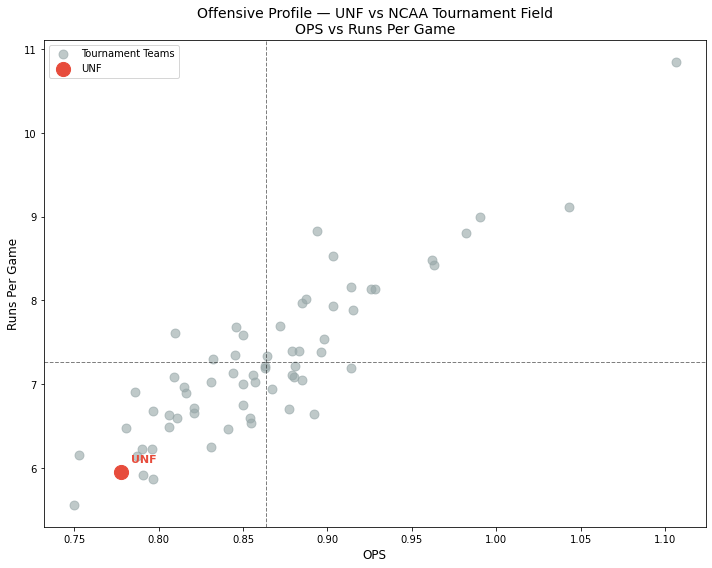

Chart 4 saved


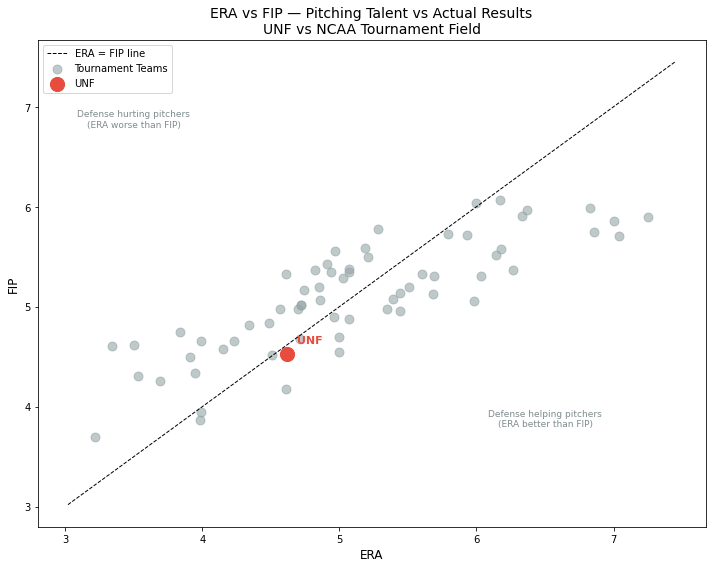

Chart 5 saved


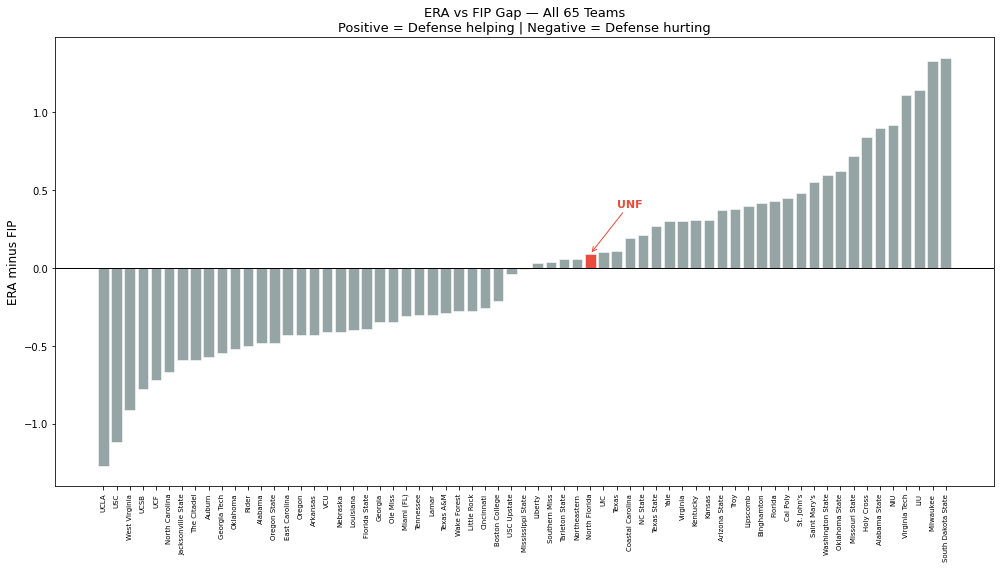

Chart 6 saved


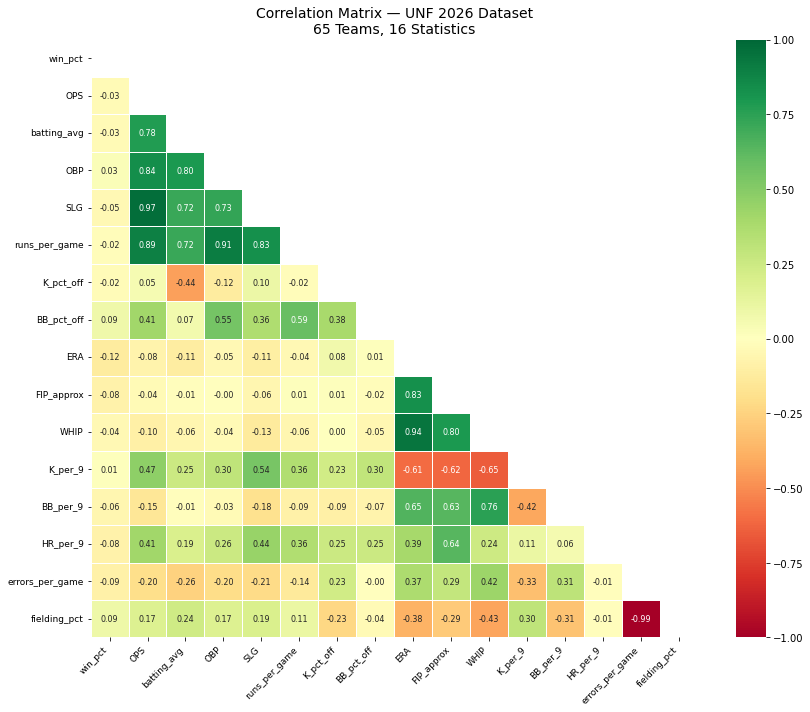

Chart 7 saved


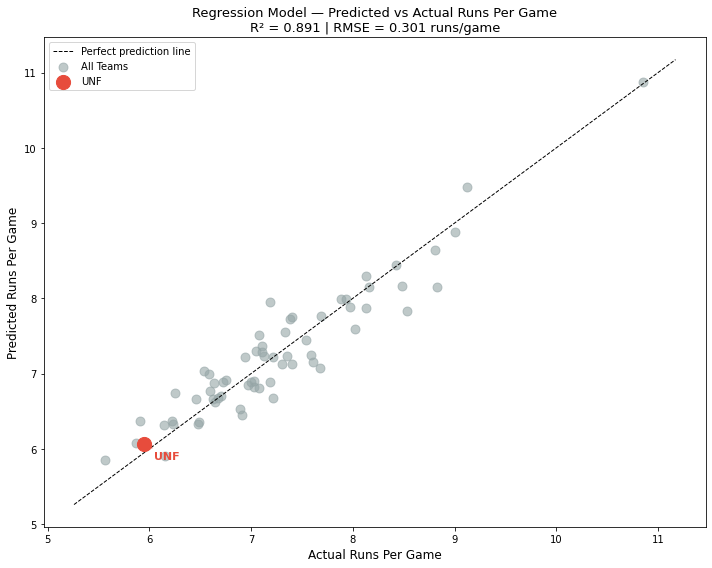

Chart 8 saved


In [5]:
# Chart 2 — Radar Chart
categories  = ['Offense', 'Pitching', 'Defense']
unf_scores  = [
    results_df[results_df['category'] == 'Offense']['percentile'].mean(),
    results_df[results_df['category'] == 'Pitching']['percentile'].mean(),
    results_df[results_df['category'] == 'Defense']['percentile'].mean(),
]
tourn_scores = [50, 50, 50]

N      = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

unf_scores_plot   = unf_scores  + unf_scores[:1]
tourn_scores_plot = tourn_scores + tourn_scores[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, unf_scores_plot,   color='#2980b9', linewidth=2, label='UNF')
ax.fill(angles, unf_scores_plot,   color='#2980b9', alpha=0.25)
ax.plot(angles, tourn_scores_plot, color='#e74c3c', linewidth=2, linestyle='--', label='Tournament Avg')
ax.fill(angles, tourn_scores_plot, color='#e74c3c', alpha=0.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=14)
ax.set_ylim(0, 100)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(['25th', '50th', '75th', '100th'], fontsize=9)
ax.set_title('UNF 2026 vs Tournament Average\nby Category', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('charts/chart2_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved")

# Chart 3 — Category Summary Bar Chart
fig, ax = plt.subplots(figsize=(8, 6))
bar_colors = []
for score in unf_scores:
    if score >= 75:
        bar_colors.append('#2ecc71')
    elif score >= 40:
        bar_colors.append('#f39c12')
    else:
        bar_colors.append('#e74c3c')

bars = ax.bar(categories, unf_scores, color=bar_colors, width=0.5, edgecolor='white')
for bar, score in zip(bars, unf_scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{round(score, 1)}th',
        ha='center', fontsize=12, fontweight='bold'
    )
ax.axhline(y=50, color='black', linestyle='--', linewidth=1, label='Tournament avg (50th)')
ax.set_ylim(0, 100)
ax.set_ylabel('Average Percentile Rank', fontsize=12)
ax.set_title('UNF 2026 — Average Percentile by Category\nvs NCAA Tournament Field', fontsize=14)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('charts/chart3_category_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved")

# Chart 4 — Offense Scatter Plot
tournament_plot = df[df['ncaa_tournament_regional'] == 1]
unf_plot        = df[df['team'] == 'North Florida']

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(tournament_plot['OPS'], tournament_plot['runs_per_game'],
           color='#95a5a6', alpha=0.6, s=80, label='Tournament Teams')
ax.scatter(unf_plot['OPS'], unf_plot['runs_per_game'],
           color='#e74c3c', s=200, zorder=5, label='UNF')
ax.annotate('UNF',
            xy=(unf_plot['OPS'].values[0], unf_plot['runs_per_game'].values[0]),
            xytext=(10, 10), textcoords='offset points',
            fontsize=11, fontweight='bold', color='#e74c3c')
ax.axvline(x=tournament_plot['OPS'].mean(),          color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(y=tournament_plot['runs_per_game'].mean(), color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('OPS', fontsize=12)
ax.set_ylabel('Runs Per Game', fontsize=12)
ax.set_title('Offensive Profile — UNF vs NCAA Tournament Field\nOPS vs Runs Per Game', fontsize=14)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('charts/chart4_offense_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved")

# Chart 5 — ERA vs FIP Scatter Plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(tournament_plot['ERA'], tournament_plot['FIP_approx'],
           color='#95a5a6', alpha=0.6, s=80, label='Tournament Teams')
ax.scatter(unf_plot['ERA'], unf_plot['FIP_approx'],
           color='#e74c3c', s=200, zorder=5, label='UNF')
ax.annotate('UNF',
            xy=(unf_plot['ERA'].values[0], unf_plot['FIP_approx'].values[0]),
            xytext=(10, 10), textcoords='offset points',
            fontsize=11, fontweight='bold', color='#e74c3c')
min_val = min(df['ERA'].min(), df['FIP_approx'].min()) - 0.2
max_val = max(df['ERA'].max(), df['FIP_approx'].max()) + 0.2
ax.plot([min_val, max_val], [min_val, max_val],
        color='black', linestyle='--', linewidth=1, label='ERA = FIP line')
ax.text(3.5, 6.8, 'Defense hurting pitchers\n(ERA worse than FIP)',
        fontsize=9, color='#7f8c8d', ha='center')
ax.text(6.5, 3.8, 'Defense helping pitchers\n(ERA better than FIP)',
        fontsize=9, color='#7f8c8d', ha='center')
ax.set_xlabel('ERA', fontsize=12)
ax.set_ylabel('FIP', fontsize=12)
ax.set_title('ERA vs FIP — Pitching Talent vs Actual Results\nUNF vs NCAA Tournament Field', fontsize=14)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('charts/chart5_era_vs_fip.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved")

# Chart 6 — ERA vs FIP Gap Chart
df['ERA_FIP_gap'] = df['ERA'] - df['FIP_approx']
df_sorted = df.sort_values('ERA_FIP_gap', ascending=True).reset_index(drop=True)

bar_colors = []
for i, row in df_sorted.iterrows():
    if row['team'] == 'North Florida':
        bar_colors.append('#e74c3c')
    else:
        bar_colors.append('#95a5a6')

fig, ax = plt.subplots(figsize=(14, 8))
ax.bar(range(len(df_sorted)), df_sorted['ERA_FIP_gap'],
       color=bar_colors, edgecolor='white', linewidth=0.5)
unf_idx = df_sorted[df_sorted['team'] == 'North Florida'].index[0]
ax.annotate('UNF',
            xy=(unf_idx, df_sorted.loc[unf_idx, 'ERA_FIP_gap']),
            xytext=(unf_idx + 2, df_sorted.loc[unf_idx, 'ERA_FIP_gap'] + 0.3),
            fontsize=11, fontweight='bold', color='#e74c3c',
            arrowprops=dict(arrowstyle='->', color='#e74c3c'))
ax.axhline(y=0, color='black', linewidth=1)
ax.set_xticks(range(len(df_sorted)))
ax.set_xticklabels(df_sorted['team'], rotation=90, fontsize=7)
ax.set_ylabel('ERA minus FIP', fontsize=12)
ax.set_title('ERA vs FIP Gap — All 65 Teams\nPositive = Defense helping | Negative = Defense hurting', fontsize=13)
plt.tight_layout()
plt.savefig('charts/chart6_era_fip_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved")

# Chart 7 — Correlation Heatmap
corr_stats = ['win_pct', 'OPS', 'batting_avg', 'OBP', 'SLG', 'runs_per_game',
              'K_pct_off', 'BB_pct_off', 'ERA', 'FIP_approx', 'WHIP',
              'K_per_9', 'BB_per_9', 'HR_per_9', 'errors_per_game', 'fielding_pct']

corr_df    = df[corr_stats].dropna()
full_corr  = corr_df.corr()
mask       = np.zeros_like(full_corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(full_corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — UNF 2026 Dataset\n65 Teams, 16 Statistics', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('charts/chart7_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved")

# Chart 8 — Regression Predicted vs Actual
reg_df = corr_df[['runs_per_game', 'OBP', 'SLG']].dropna()
X      = reg_df[['OBP', 'SLG']]
y      = reg_df['runs_per_game']

model     = LinearRegression()
model.fit(X, y)
y_pred    = model.predict(X)
r2        = r2_score(y, y_pred)
rmse      = mean_squared_error(y, y_pred) ** 0.5

unf_pred  = model.predict([[unf['OBP'], unf['SLG']]])[0]

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(y, y_pred, color='#95a5a6', alpha=0.6, s=80, label='All Teams')
ax.scatter(unf['runs_per_game'], unf_pred,
           color='#e74c3c', s=200, zorder=5, label='UNF')
ax.annotate('UNF',
            xy=(unf['runs_per_game'], unf_pred),
            xytext=(10, -15), textcoords='offset points',
            fontsize=11, fontweight='bold', color='#e74c3c',
            arrowprops=dict(arrowstyle='->', color='#e74c3c'))
min_val = min(y.min(), y_pred.min()) - 0.3
max_val = max(y.max(), y_pred.max()) + 0.3
ax.plot([min_val, max_val], [min_val, max_val],
        color='black', linestyle='--', linewidth=1, label='Perfect prediction line')
ax.set_xlabel('Actual Runs Per Game', fontsize=12)
ax.set_ylabel('Predicted Runs Per Game', fontsize=12)
ax.set_title(f'Regression Model — Predicted vs Actual Runs Per Game\nR² = {round(r2, 3)} | RMSE = {round(rmse, 3)} runs/game', fontsize=13)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('charts/chart8_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 8 saved")

## Section 5 — Regression Model and What If Scenarios
Linear regression predicting runs per game from OBP and SLG.
R-squared of 0.891 confirms OBP and SLG explain 89% of run
production variance across 65 Division I programs.

In [6]:
# Regression results and what if scenarios
unf_obp   = unf['OBP']
unf_slg   = unf['SLG']
tourn_obp = tournament['OBP'].mean()
tourn_slg = tournament['SLG'].mean()

unf_predicted   = model.predict([[unf_obp,   unf_slg]])[0]
tourn_predicted = model.predict([[tourn_obp, tourn_slg]])[0]
obp_improvement = model.predict([[tourn_obp, unf_slg]])[0]
slg_improvement = model.predict([[unf_obp,   tourn_slg]])[0]
both            = model.predict([[tourn_obp, tourn_slg]])[0]

print("=== MODEL PERFORMANCE ===")
print(f"R-squared:  {round(r2, 3)}")
print(f"RMSE:       {round(rmse, 3)} runs per game")

print("\n=== MODEL COEFFICIENTS ===")
print(f"OBP coefficient: {round(model.coef_[0], 3)}")
print(f"SLG coefficient: {round(model.coef_[1], 3)}")
print(f"Intercept:       {round(model.intercept_, 3)}")
print(f"\nEquation: Runs/Game = ({round(model.coef_[0], 3)} x OBP) + ({round(model.coef_[1], 3)} x SLG) + ({round(model.intercept_, 3)})")

print("\n=== UNF OFFENSIVE PROJECTION ===")
print(f"UNF actual OBP:        {round(unf_obp, 3)}")
print(f"UNF actual SLG:        {round(unf_slg, 3)}")
print(f"Tournament avg OBP:    {round(tourn_obp, 3)}")
print(f"Tournament avg SLG:    {round(tourn_slg, 3)}")
print(f"\nUNF actual runs/game:      {round(unf['runs_per_game'], 2)}")
print(f"UNF predicted runs/game:   {round(unf_predicted, 2)}")
print(f"Tournament avg runs/game:  {round(tourn_predicted, 2)}")

print("\n=== WHAT IF SCENARIOS ===")
print(f"Raise OBP to tournament avg ({round(tourn_obp, 3)}), keep SLG same:")
print(f"  Projected runs/game: {round(obp_improvement, 2)}")
print(f"  Gain: +{round(obp_improvement - unf_predicted, 2)} runs per game")

print(f"\nRaise SLG to tournament avg ({round(tourn_slg, 3)}), keep OBP same:")
print(f"  Projected runs/game: {round(slg_improvement, 2)}")
print(f"  Gain: +{round(slg_improvement - unf_predicted, 2)} runs per game")

print(f"\nRaise BOTH to tournament averages:")
print(f"  Projected runs/game: {round(both, 2)}")
print(f"  Gain: +{round(both - unf_predicted, 2)} runs per game")
print(f"  Over 55 games:       +{round((both - unf_predicted) * 55, 0)} additional runs scored")

# Save outputs
results_df.to_csv('data/unf_benchmarking_results.csv', index=False)
df.to_csv('data/team_benchmarks_clean.csv', index=False)
print("\nAll outputs saved to data folder")

=== MODEL PERFORMANCE ===
R-squared:  0.891
RMSE:       0.301 runs per game

=== MODEL COEFFICIENTS ===
OBP coefficient: 33.874
SLG coefficient: 6.471
Intercept:       -9.082

Equation: Runs/Game = (33.874 x OBP) + (6.471 x SLG) + (-9.082)

=== UNF OFFENSIVE PROJECTION ===
UNF actual OBP:        0.369
UNF actual SLG:        0.409
Tournament avg OBP:    0.393
Tournament avg SLG:    0.47

UNF actual runs/game:      5.95
UNF predicted runs/game:   6.06
Tournament avg runs/game:  7.26

=== WHAT IF SCENARIOS ===
Raise OBP to tournament avg (0.393), keep SLG same:
  Projected runs/game: 6.87
  Gain: +0.8 runs per game

Raise SLG to tournament avg (0.47), keep OBP same:
  Projected runs/game: 6.46
  Gain: +0.39 runs per game

Raise BOTH to tournament averages:
  Projected runs/game: 7.26
  Gain: +1.2 runs per game
  Over 55 games:       +66.0 additional runs scored

All outputs saved to data folder


## Section 6 — Key Findings and Recommendations

### Diagnosis
UNF's 2026 season reveals a team with a tournament caliber
pitching staff being undermined by a critically weak offense
and poor defensive unit.

- Pitching: 67.7th percentile — FIP ranks 85.9th percentile,
  HR/9 allowed ranks 100th percentile vs tournament field
- Offense: 14.4th percentile — OPS, OBP, SLG, and wOBA all
  rank below 10th percentile vs tournament field
- Defense: 10.2th percentile — errors per game and fielding
  percentage both rank bottom 11% vs tournament field

### Regression Model Findings
OBP is twice as impactful as SLG in predicting run production.
Raising both to tournament averages projects to add 1.20 runs
per game — approximately 66 additional runs over a full season.

### Recruiting Archetypes
1. High contact, high discipline hitter — OBP above .390,
   K% below 20%, BB% above 12%
2. Plus defender at premium position — shortstop, center
   field, or catcher with fielding percentage above .975
3. Power bat with pitch recognition — ISO above .200,
   SLG above .480, K% below 25%

### Methodology Notes
- Dataset specific FIP constant of 4.16 calculated from
  65 team sample replacing MLB standard of 3.10
- Percentile rankings calculated vs 64 team tournament
  field excluding UNF from its own benchmark group
- Linear regression R-squared of 0.891, RMSE of 0.301
- All analysis conducted in Python using pandas, numpy,
  matplotlib, seaborn, and scikit-learn

In [7]:
# Final file check
import os

print("=== FINAL PROJECT FILE CHECK ===")

charts = [
    'charts/chart1_gap_bar.png',
    'charts/chart2_radar.png',
    'charts/chart3_category_summary.png',
    'charts/chart4_offense_scatter.png',
    'charts/chart5_era_vs_fip.png',
    'charts/chart6_era_fip_gap.png',
    'charts/chart7_correlation_matrix.png',
    'charts/chart8_regression.png',
]

data_files = [
    'data/unf_benchmarking_results.csv',
    'data/team_benchmarks_clean.csv',
]

all_good = True

print("\nCharts:")
for f in charts:
    if os.path.exists(f):
        print(f"  {f} — saved")
    else:
        print(f"  MISSING: {f}")
        all_good = False

print("\nData files:")
for f in data_files:
    if os.path.exists(f):
        print(f"  {f} — saved")
    else:
        print(f"  MISSING: {f}")
        all_good = False

if all_good:
    print("\nAll files confirmed. Notebook complete.")
    print("Ready for GitHub upload.")
else:
    print("\nSome files missing. Re-run the relevant cells.")

=== FINAL PROJECT FILE CHECK ===

Charts:
  charts/chart1_gap_bar.png — saved
  charts/chart2_radar.png — saved
  charts/chart3_category_summary.png — saved
  charts/chart4_offense_scatter.png — saved
  charts/chart5_era_vs_fip.png — saved
  charts/chart6_era_fip_gap.png — saved
  charts/chart7_correlation_matrix.png — saved
  charts/chart8_regression.png — saved

Data files:
  data/unf_benchmarking_results.csv — saved
  data/team_benchmarks_clean.csv — saved

All files confirmed. Notebook complete.
Ready for GitHub upload.
